In [1]:
import pandas as pd
import ast
import re
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt

_root = Path.cwd()
while not (_root / "src").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src import config, analysis

TRAIN_PATH  = config.TRAIN_PATH
INPUT_FILE = config.DATA_DIR / "all_col_names.csv"
OUTPUT_FILE = config.DATA_DIR / "bitcoin_metrics_full_classification_final.csv"
FIGURES_DIR = config.FIGURES_DIR


In [2]:
# Convert the tokens column into a usable list
# If tokens is missing or malformed, fall back to splitting the column name
def safe_tokenize(row):
    name = str(row["column_name"]).lower()

    try:
        if "tokens" in row and isinstance(row["tokens"], str):
            tokens = ast.literal_eval(row["tokens"])
        elif "tokens" in row:
            tokens = row["tokens"]
        else:
            tokens = name.split("_")

        tokens = [str(t).lower() for t in tokens]

    except Exception:
        tokens = name.split("_")

    return tokens

In [3]:
# First meaningful token
def extract_root(tokens):
    return tokens[0] if len(tokens) > 0 else "none"


# Second meaningful token
def extract_sub_root(tokens):
    return tokens[1] if len(tokens) > 1 else "none"


# Extract time windows like 7d, 1m, 1y
def extract_time_horizon(tokens):
    time_pattern = re.compile(r"^_?\d+[dwmyh]$")
    horizons = [t.strip("_") for t in tokens if time_pattern.match(t)]
    return ",".join(horizons) if horizons else "spot"


# Extract units from the metric name
def extract_unit(tokens):
    units = [
        "usd", "btc", "sats", "sat",
        "cents", "percent", "pct"
    ]

    found = [t for t in tokens if t in units]
    return "_".join(found) if found else "none"


# Extract a broad metric type label from known keywords
def extract_metric_type(tokens):
    time_pattern = re.compile(r"^_?\d+[dwmyh]$")
    subject_tokens = [t for t in tokens if not time_pattern.match(t)]

    metric_keywords = [
        "price", "ratio", "mvrv", "sma", "ema",
        "returns", "return", "cap", "supply",
        "profit", "loss", "pnl", "cagr",
        "stack", "count", "dominance", "flow",
        "sopr", "nupl", "nvt", "sent",
        "received", "fee", "fees", "subsidy",
        "reward", "value", "basis", "cost",
        "difficulty", "hash", "hashrate", "volume",
        "drawdown", "velocity", "index",
        "rsi", "macd", "stoch", "puell",
        "reserve", "sortino", "downside",
        "coinbase", "blocks", "mined",
        "cumulative", "average", "median",
        "max", "min", "sum", "utxo"
    ]

    found = [t for t in subject_tokens if t in metric_keywords]
    return "_".join(found) if found else (subject_tokens[-1] if subject_tokens else "none")



In [4]:
# Build a simplified stem by removing time horizons and common suffixes
def create_stem(col):
    col = str(col).lower()

    col = re.sub(r"_(_?\d+[dwmyh])_", "_", col)
    col = re.sub(r"_(_?\d+[dwmyh])$", "", col)

    suffixes_to_remove = [
        "_cents", "_sats", "_sat", "_usd", "_btc",
        "_0sd_usd", "_sma", "_ema", "_ratio",
        "_zscore", "_z_score", "_normalized", "_standardized"
    ]

    changed = True

    while changed:
        changed = False
        for suffix in suffixes_to_remove:
            if col.endswith(suffix):
                col = col[:-len(suffix)]
                changed = True

    col = re.sub(r"__+", "_", col)
    col = col.strip("_")
    return col

In [5]:
# Parse one metric name into structured metadata fields
def parse_column(row):
    name = str(row["column_name"]).lower()
    tokens = safe_tokenize(row)

    time_pattern = re.compile(r"^_?\d+[dwmyh]$")
    subject_tokens = [t for t in tokens if not time_pattern.match(t)]

    root = extract_root(subject_tokens)
    sub_root = extract_sub_root(subject_tokens)

    metric_type = extract_metric_type(tokens)
    time_horizon = extract_time_horizon(tokens)
    unit = extract_unit(tokens)
    family = analysis.assign_category(name)
    stem = create_stem(name)

    # Cluster key groups similar columns together for later reduction
    cluster_key = (
        str(family)
        + " | root=" + str(root)
        + " | sub_root=" + str(sub_root)
        + " | type=" + str(metric_type)
        + " | time=" + str(time_horizon)
        + " | unit=" + str(unit)
    )

    return pd.Series([
        root, sub_root, metric_type, time_horizon, unit,
        family, stem, cluster_key
    ])



In [6]:
# Read input file
# Then load it:
df = pd.read_csv(INPUT_FILE)

# Clean the metric names
df["column_name"] = df["column_name"].astype(str).str.strip()
df = df[df["column_name"] != ""]

# Create parsed metadata columns
df[
    [
        "root", "sub_root", "metric_type", "time_horizon", "unit",
        "family", "stem", "cluster_key"
    ]
] = df.apply(parse_column, axis=1)

# Remove duplicated columns if any were introduced
df = df.loc[:, ~df.columns.duplicated()]

# Save output
os.makedirs("outputs", exist_ok=True)
df.to_csv(OUTPUT_FILE, index=False)

print(f"Success! Full classification saved to: {OUTPUT_FILE}")
print("\nFamily counts:")
print(df["family"].value_counts())

Success! Full classification saved to: C:\Users\Shruti\OneDrive\Desktop\UBC\DSCI591\DevBranch\AdaptiveSats\data\bitcoin_metrics_full_classification_final.csv

Family counts:
family
UTXO Age Cohorts                   18342
Price                               6050
Address Distribution by Balance     5250
Age & Halving Cohorts               2737
Entities                            2368
Address Activity by Tech Type       1732
Pool-Specific Economics             1612
Network Activity                    1415
Holder Cohorts                       842
Market & Valuation                   370
Benchmarks & DCA                     369
Supply & Scarcity                    130
Profitability & SOPR                 117
Block Reward Distributions            27
Technical Indicators                  25
Metadata                              22
Name: count, dtype: int64


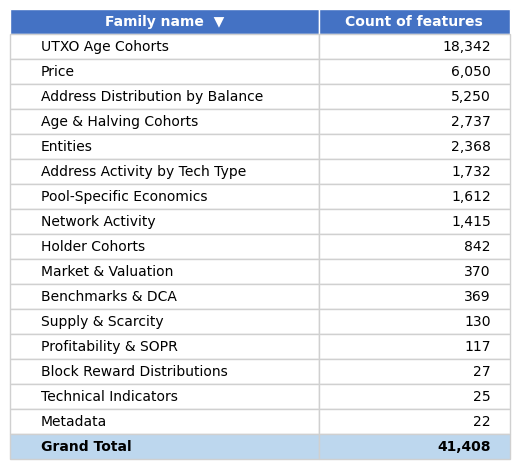

In [7]:
# Build summary table
counts = df["family"].value_counts().reset_index()
counts.columns = ["Family name", "Count of features"]

grand_total = pd.DataFrame(
    [["Grand Total", counts["Count of features"].sum()]],
    columns=["Family name", "Count of features"]
)
counts = pd.concat([counts, grand_total], ignore_index=True)

# Format count column as integers with comma separators
counts["Count of features"] = counts["Count of features"].apply(lambda x: f"{x:,}")

# Layout
n_rows = len(counts)
fig, ax = plt.subplots(figsize=(5, (n_rows + 1) * 0.25))
ax.axis("off")

table = ax.table(
    cellText=counts.values,
    colLabels=["Family name  ▼", "Count of features"],
    cellLoc="left",
    bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
#table.set_fontsize(9.5)
table.auto_set_column_width([0, 1])
table.scale(1, 0.50)

HEADER_BG   = "#4472C4"
HEADER_FG   = "white"
TOTAL_BG    = "#BDD7EE"

# Style header
for col in range(2):
    cell = table[0, col]
    cell.set_facecolor(HEADER_BG)
    cell.set_text_props(color=HEADER_FG, fontweight="bold")
    cell.set_edgecolor("white")

# Style data rows
for row in range(1, n_rows + 1):
    is_total = (row == n_rows)
    for col in range(2):
        cell = table[row, col]
        if is_total:
            cell.set_facecolor(TOTAL_BG)
            cell.set_text_props(fontweight="bold")
        cell.set_edgecolor("#D0D0D0")
        # Right-align count column
        if col == 1:
            cell.set_text_props(ha="right")

plt.subplots_adjust(top=1, bottom=0, left=0, right=1)
plt.savefig(FIGURES_DIR / "feature_count_by_family.png", bbox_inches="tight", pad_inches=0.05)
plt.show()
